In [5]:
#Żeby dało się odnieść do plików w src
%pip install -e .. 

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///c:/Users/Orze%C5%82/Desktop/Studia/sem6/CUDA/Deep-Learning-Terrain-Generator
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for Deep-Learning-Terrain-Generator (pyproject.toml): started
  Building editable for Deep-Learning-Terrain-Generator (pyproject.toml): finished with status 'done'
  Created wheel for Deep-Learning-Terrain-Generator: filename=deep_learning_terrain_generator-0.1.0-0.editable-py3-none-any.whl size=1726 sha256=2c

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from config import RESOLUTION, PROCESSED_DATA_DIR, TILE_SIZE

tensor_path = PROCESSED_DATA_DIR / f"worldclim_{RESOLUTION}_full.npy"

dataset_numpy = np.load(tensor_path, mmap_mode='r')

print(f"Loaded Array Shape: {dataset_numpy.shape}")

Loaded Array Shape: (3, 1080, 2160)


In [8]:
def visualize_terrain_data(data_input, title_prefix="WorldClim"):
    """
    Visualizes the 3-channel PyTorch tensor (Elevation, Precipitation, Temperature).
    Expects shape: [3, Height, Width]
    """
    if torch.is_tensor(data_input):
        data = data_input.cpu().numpy()
    else:
        data = data_input
    
    elev = data[0]
    precip = data[1]
    temp = data[2]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"{title_prefix} Normalized Training Data", fontsize=18, fontweight='bold')

    im0 = axes[0].imshow(elev, cmap='terrain', vmin=0, vmax=1)
    axes[0].set_title("Elevation")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(precip, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title("Annual Precipitation")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(temp, cmap='coolwarm', vmin=0, vmax=1)
    axes[2].set_title("Annual Avg Temperature")
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

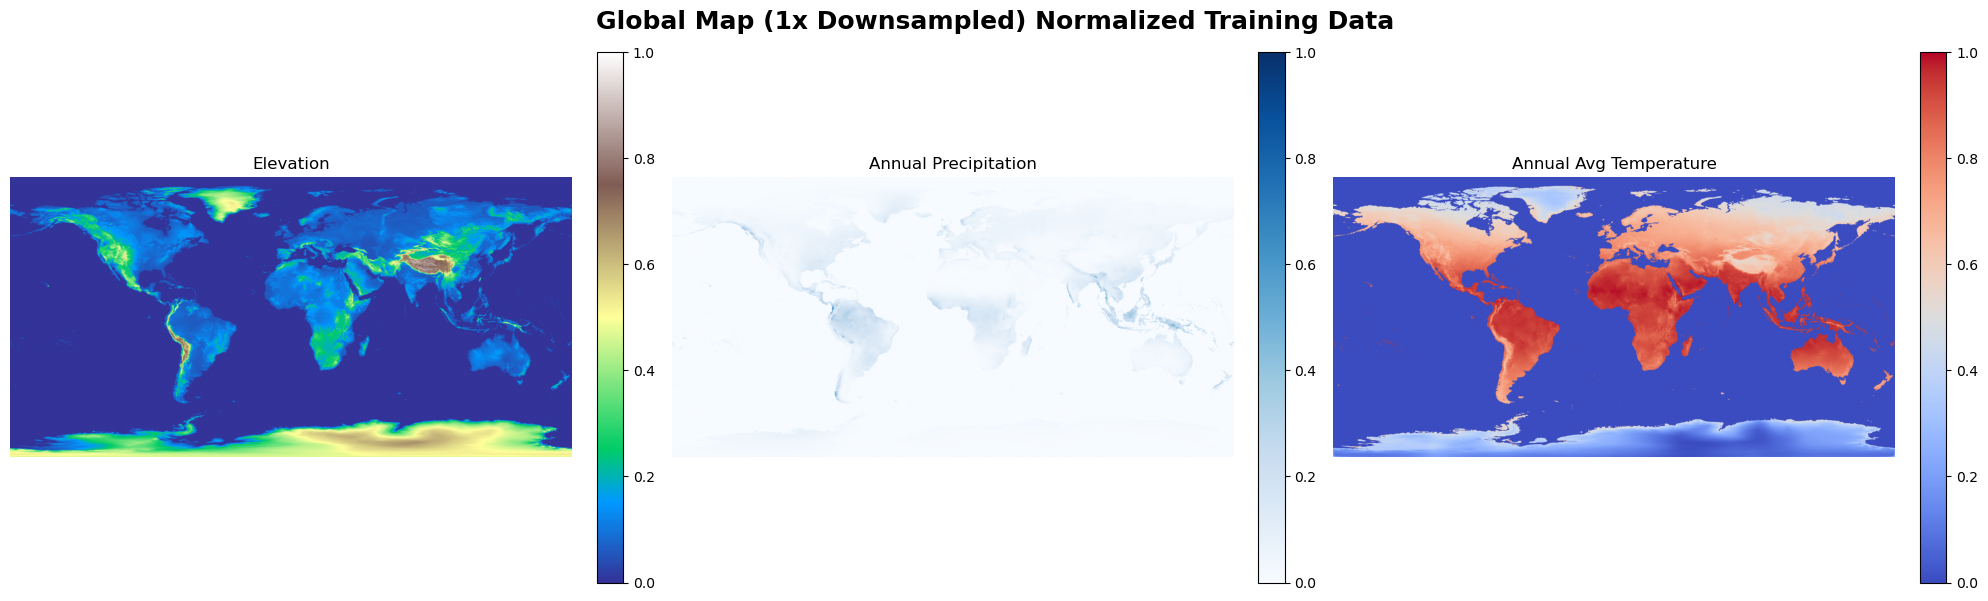

In [12]:
step = 1

downsampled_global = dataset_numpy[:, ::step, ::step] # Renderowanie całości przeładowuje mi RAM

visualize_terrain_data(downsampled_global, title_prefix=f"Global Map ({step}x Downsampled)")

C:\Users\Orzeł\AppData\Local\Temp\ipykernel_8368\3942968768.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\bld\libtorch_1772176597925\work\torch\csrc\utils\tensor_numpy.cpp:219.)
  patch_tensor = torch.from_numpy(patch_numpy).float()


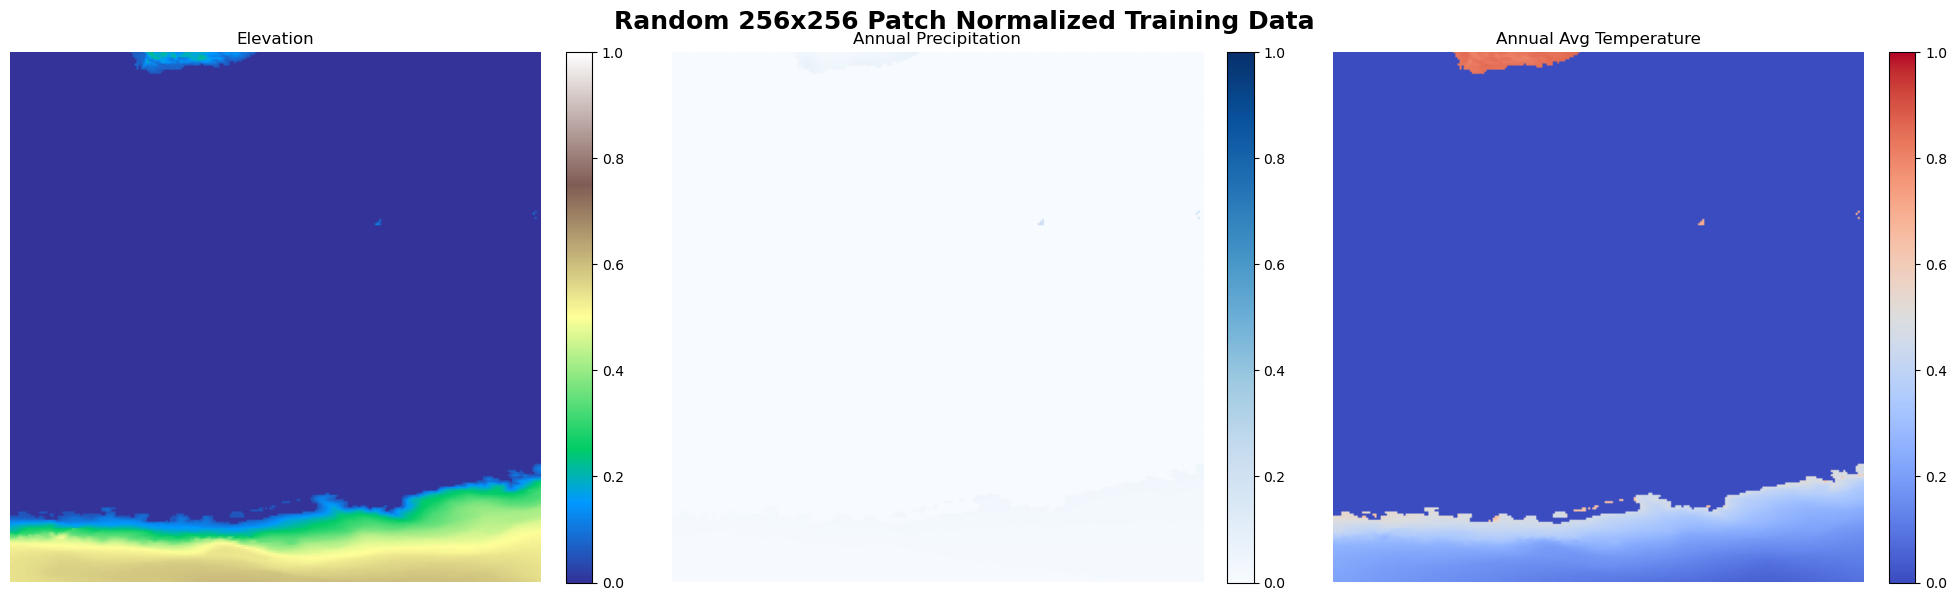

In [13]:
C, H, W = dataset_numpy.shape

y = np.random.randint(0, H - TILE_SIZE)
x = np.random.randint(0, W - TILE_SIZE)

patch_numpy = dataset_numpy[:, y:y+TILE_SIZE, x:x+TILE_SIZE]

patch_tensor = torch.from_numpy(patch_numpy).float()

visualize_terrain_data(patch_tensor, title_prefix=f"Random {TILE_SIZE}x{TILE_SIZE} Patch")

In [14]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src"))

from dataset import get_dataloader

dataloader = get_dataloader(batch_size=4)
batch = next(iter(dataloader))

print(f"Batch Shape: {batch.shape}")

Batch Shape: torch.Size([4, 3, 256, 256])
